#### Initialize the libraries, the environment and the client

In [1]:
import pandas as pd
import os
from pprint import pprint

try:
    from epo.tipdata.ops import OPSClient, models, exceptions
except ImportError:
    os.system('pip install epo-tipdata-ops')
    from epo.tipdata.ops import OPSClient, models, exceptions

%load_ext dotenv
%dotenv
%load_ext autoreload
%autoreload 2
    
client = OPSClient(
    key=os.getenv("OPS_KEY"), secret=os.getenv("OPS_SECRET")
)

### 7.5  published_data_search Method
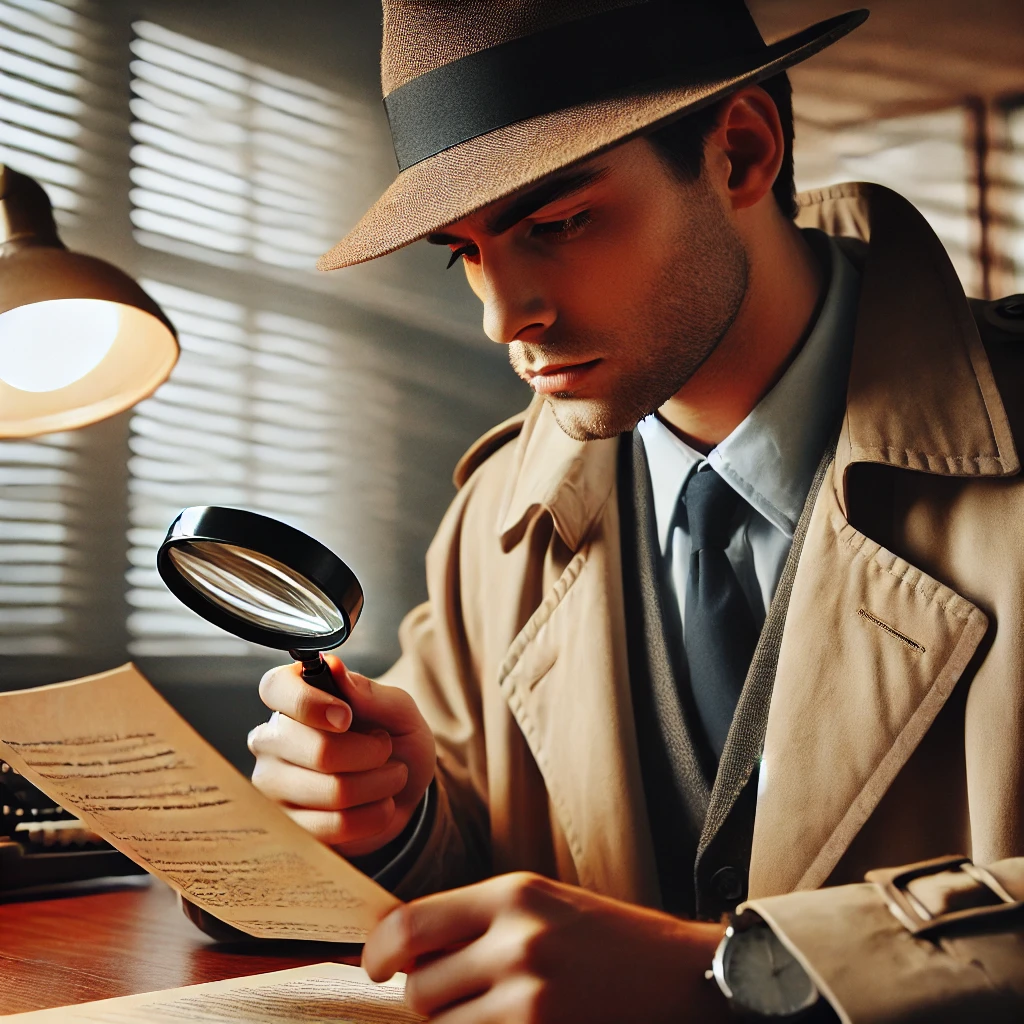

https://files.oaiusercontent.com/file-YAhwpIWabtKUggsTNh9OkjW9?se=2024-10-09T12%3A43%3A29Z&sp=r&sv=2024-08-04&sr=b&rscc=max-age%3D604800%2C%20immutable%2C%20private&rscd=attachment%3B%20filename%3D8a1a127a-a518-4917-a3e7-ac425bc59810.webp&sig=MhEY12uf/SO9j4GMafHCNq1/qtIxyGYJ%2B/fhL8EhL40%3D

The image generated above is free of any pre-existing copyright as it was created by AI based on the description you provided. Therefore, it is free of use without concerns regarding copyright infringement.


#### 7.5.1 published_data_search(cql, range_begin, range_end, constituents, output_type)
* Conducts a CQL search on the OPS database to identify patents matching your specified criteria.<br>
* Parameters:<br>
```cql (str)```: CQL search query string<br>
```range_begin (int, optional)```: Starting position of the results (defaults to 1)<br>
```range_end (int, optional)```: Maximum number of results to retrieve (defaults to 25)<br>
```constituents (list[str], optional)```: Additional elements to retrieve with bibliographic data (e.g., "biblio", "abstract")<br>
```output_type (str)```: Format of the returned data (raw XML or Pandas DataFrame)<br>

#### 7.5.2 Example of an espacenet-like search
This example searches for published patent applications based on a CQL (Common Query Language) query within a corpus (collection of text data) and display the results in a Pandas dataframe. The process will consist in:

#### 7.5.2.1 Extracting Patent Document Data Using EPO OPS API by initiating a search request with a CQL query: Explanation
* a. We define Document Range:<br>
 ```doc_start = 1``` and ```doc_stop = 100```<br>
These lines define the range of documents to be retrieved. It searches from document number 1 (inclusive) to document number 100 (inclusive).<br>
* b. We search for Documents:<br>
 ```content = client.published_data_search(...)``` This line calls a method named ```published_data_search```. This method is used to search for documents based on a provided query, so to send a search request to the EPO OPS API. <br>
* c. We pass arguments to the method:<br>
```cql='txt="US" prox/distance < 3 txt="application"'```: This argument specifies the search query (cql) looks for instances where "US" is found near "application" within three words (prox/distance < 3).<br>
```range_begin=doc_start```: This argument sets the starting document number for the search (1 in this case).<br>
```range_end=doc_stop```: This argument sets the ending document number for the search (100 in this case). <br>
```output_type="Dataframe"```: This argument specifies the desired output format as a Pandas DataFrame.<br>

In [2]:
doc_start = 1
doc_stop = 100

xml_content = client.published_data_search(
# cql='ab all "bobo"', 
    # cql='ti all "training model"', 
    cql='txt="US" prox/distance < 3 txt="application"', 
    # cql='ct=EP0351918',
    # cql='pn=epb',
    range_begin=doc_start, 
    range_end=doc_stop, 
    output_type="raw"
)
pprint(xml_content[:1000])

('<?xml version="1.0" encoding="UTF-8"?><?xml-stylesheet type="text/xsl" '
 'href="../../../style/exchange.xsl"?>\n'
 '<ops:world-patent-data xmlns="http://www.epo.org/exchange" '
 'xmlns:ops="http://ops.epo.org" xmlns:xlink="http://www.w3.org/1999/xlink">\n'
 '    <ops:biblio-search total-result-count="246">\n'
 '        <ops:query syntax="CQL">txt = US prox/distance&lt;3 txt = '
 'application</ops:query>\n'
 '        <ops:range begin="1" end="100"/>\n'
 '        <ops:search-result>\n'
 '            <ops:publication-reference system="ops.epo.org" '
 'family-id="93468262">\n'
 '                <document-id document-id-type="docdb">\n'
 '                    <country>NL</country>\n'
 '                    <doc-number>2039511</doc-number>\n'
 '                    <kind>A</kind>\n'
 '                </document-id>\n'
 '            </ops:publication-reference>\n'
 '            <ops:publication-reference system="ops.epo.org" '
 'family-id="81449219">\n'
 '                <document-id document

In [3]:
# Reset to default options if needed with pd.reset_option('display.max_colwidth')
pd.set_option('display.max_colwidth', 200000)

df = client.published_data_search(
    # cql='ab all "bobo"', 
    # cql='ti all "training model"', 
    cql='txt="US" prox/distance < 3 txt="application"', 
    # cql='pn=epb and pd=20241106',
    range_begin=doc_start, 
    range_end=doc_stop, 
    # constituents=['full-cycle'],
    output_type="dataframe"
)
display(df)
print(df)

,ops:publication-reference|system,ops:publication-reference|family-id,ops:publication-reference|document-id
0,ops.epo.org,93468262,"{'@document-id-type': 'docdb', 'country': 'NL', 'doc-number': '2039511', 'kind': 'A'}"
1,ops.epo.org,81449219,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '2024287133', 'kind': 'B1'}"
2,ops.epo.org,93255926,"{'@document-id-type': 'docdb', 'country': 'WO', 'doc-number': '2024224396', 'kind': 'A1'}"
3,ops.epo.org,91107973,"{'@document-id-type': 'docdb', 'country': 'WO', 'doc-number': '2024109695', 'kind': 'A1'}"
4,ops.epo.org,89381556,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '2023299303', 'kind': 'A1'}"
...,...,...,...
95,ops.epo.org,68052365,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '201817712', 'kind': 'S'}"
96,ops.epo.org,68052365,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '201817710', 'kind': 'S'}"
97,ops.epo.org,66546969,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '201814968', 'kind': 'S'}"
98,ops.epo.org,66479805,"{'@document-id-type': 'docdb', 'country': 'AU', 'doc-number': '201814909', 'kind': 'S'}"


   ops:publication-reference|system ops:publication-reference|family-id  \
0                       ops.epo.org                            93468262   
1                       ops.epo.org                            81449219   
2                       ops.epo.org                            93255926   
3                       ops.epo.org                            91107973   
4                       ops.epo.org                            89381556   
..                              ...                                 ...   
95                      ops.epo.org                            68052365   
96                      ops.epo.org                            68052365   
97                      ops.epo.org                            66546969   
98                      ops.epo.org                            66479805   
99                      ops.epo.org                            66173502   

                                                        ops:publication-reference|document-id  
0  

#### 7.5.2.2 Parsing XML Content
* Parse the XML content
* Define namespaces

In [4]:
import pandas as pd
import xml.etree.ElementTree as ET
from pprint import pprint
import time

# Parse the XML content
root = ET.fromstring(xml_content)

# Define namespaces
namespaces = {
    'ops': 'http://ops.epo.org',
    'ex': 'http://www.epo.org/exchange'  # Default namespace for the document IDs
}

#### 7.5.2.3 Automating Patent Publication Search and Data Extraction with Python
* Extract total-result-count from the response header or root (if available)
* Extract publiation data, like country code, doc number, and kind code
* Create a DataFrame from the extracted data
* Display the DataFrame and print its size in rows and columns

In [5]:
# List to hold extracted data
data = []

# Extract total-result-count from the response header or root (if available)
result_count = root.attrib.get('total-result-count', None)

if result_count:
    print(f"Total number of results: {result_count}")
else:
    print("Total result count not found in the response.")
        
# Extract country code, doc number, and kind code from each publication reference
for pub_ref in root.findall('.//ops:publication-reference', namespaces):
    doc_id = pub_ref.find('.//ex:document-id', namespaces)
    if doc_id is not None:
        country = doc_id.find('ex:country', namespaces).text
        doc_number = doc_id.find('ex:doc-number', namespaces).text
        kind = doc_id.find('ex:kind', namespaces).text if doc_id.find('ex:kind', namespaces) is not None else None
            
        # Append to data list
        data.append({
            'Country Code': country,
            'Document Number': doc_number,
            'Kind Code': kind
        })
        
# Create a DataFrame from the extracted data
df = pd.DataFrame(data)
# Check if the DataFrame is empty
if df.empty:
    print("DataFrame is empty.")
        
# Display the DataFrame
print(df.head())
print(df.tail())    
    
# Print the size of the DataFrame (rows, columns)
print(f"DataFrame size: {df.shape[0]} rows, {df.shape[1]} columns.")

Total result count not found in the response.
  Country Code Document Number Kind Code
0           NL         2039511         A
1           AU      2024287133        B1
2           WO      2024224396        A1
3           WO      2024109695        A1
4           AU      2023299303        A1
   Country Code Document Number Kind Code
95           AU       201817712         S
96           AU       201817710         S
97           AU       201814968         S
98           AU       201814909         S
99           CA         3081946        A1
DataFrame size: 100 rows, 3 columns.


#### 7.5.2.4 Listing highlighted patent descriptions and iterating through a DataFrame containing document IDs. 
For each document, this code fetches a patent description, highlights specific terms like the proximate words "US" near "application", and organizes the results in a DataFrame for further analysis or reporting. The inclusion of error handling and rate limiting enhances its robustness and usability in a production environment.

In [6]:
# Initialize an empty list to store highlighted descriptions
highlighted_descriptions = []

# Loop through each document ID
for index, row in df.iterrows():
    # print("row", row)
    country_code = row['Country Code']  # Get the country code
    doc_id = row['Document Number']      # Get the document number
    kind_code = row['Kind Code']          # Optionally capture the kind code
    # print("doc_id:", doc_id)
    
    try:
        # Construct input for the published_data method
        description = client.published_data(
            reference_type='publication',
            input=models.Docdb(doc_id, country_code, kind_code, date=None),  # Use all required params
            endpoint='description',
            constituents=[],            
            output_type='raw'
        )
        
        # Highlight the target word "application"
        highlighted_text = description.replace("application", "<mark>application</mark>")                    
        
        # Print the description when it's not None
        if highlighted_text is not None:
            # Append the highlighted description to the list
            highlighted_descriptions.append(highlighted_text)            
            print(f"Description for {doc_id}:")
            print(highlighted_text[:2000])
            print()
    except Exception as e:
        # print(f"Error fetching description for {doc_id}: {e}")
        highlighted_descriptions.append(None)  # Append None if there's an error
    
    # Optional: Add a delay to prevent hitting rate limits
    time.sleep(1)

# Convert the list to a DataFrame for better handling
highlighted_df = pd.DataFrame({
    'Document ID': df['Document Number'],  # Using the correct column name from the original DataFrame
    'Highlighted Description': highlighted_descriptions
})

# Display the DataFrame with highlighted descriptions
# pprint(highlighted_df)


Description for 2024224396:
<?xml version="1.0" encoding="UTF-8"?><?xml-stylesheet type="text/xsl" href="../../../../../style/pub-ftxt-description.xsl"?>
<ops:world-patent-data xmlns="http://www.epo.org/exchange" xmlns:ops="http://ops.epo.org" xmlns:xlink="http://www.w3.org/1999/xlink"><ftxt:fulltext-documents xmlns="http://www.epo.org/fulltext" xmlns:ftxt="http://www.epo.org/fulltext"><ftxt:fulltext-document system="ops.epo.org" fulltext-format="text-only"><bibliographic-data><publication-reference data-format="docdb"><document-id><country>WO</country><doc-number>2024224396</doc-number><kind>A1</kind></document-id></publication-reference></bibliographic-data><description lang="EN"><p>A WEARABLE DEVICE FOR APPLYING ULTRASONIC PULSES ON A BLOOD VESSEL OR A TISSUE OF A SUBJECT </p><p>FIELD OF THE INVENTION </p><p>The present invention relates generally to a wearable device that delivers therapeutic energy to a patient. More specifically, it relates to an ultrasonic device, adapted to aff

In [7]:
epodoc = client.number(
    reference_type="application",
    # input=models.Docdb("62/570,391", "US", "A", "20171010"), 
    input=models.Original("62/570,391", "US", "A", "20171010"),
    output_format="epodoc",
    output_type="dataframe"
)
# Print the converted Epodoc number
print(f"Converted Epodoc number: {epodoc}")
epodoc

Converted Epodoc number:   inputFormat outputFormat  \
0    original       epodoc   

                                                                   ops:input|ops:application-reference|document-id  \
0  {'@document-id-type': 'original', 'country': 'US', 'doc-number': '62/570,391', 'kind': 'A', 'date': '20171010'}   

                                                    ops:output|ops:application-reference|document-id  
0  {'@document-id-type': 'epodoc', 'doc-number': 'US201762570391P', 'kind': 'P', 'date': '20171010'}  


,inputFormat,outputFormat,ops:input|ops:application-reference|document-id,ops:output|ops:application-reference|document-id
0,original,epodoc,"{'@document-id-type': 'original', 'country': 'US', 'doc-number': '62/570,391', 'kind': 'A', 'date': '20171010'}","{'@document-id-type': 'epodoc', 'doc-number': 'US201762570391P', 'kind': 'P', 'date': '20171010'}"


In [8]:
# Check the column names in the epodoc DataFrame
print(epodoc.columns)

# Extract the relevant fields from the DataFrame
input_doc_info = epodoc["ops:input|ops:application-reference|document-id"].iloc[0]
output_doc_info = epodoc["ops:output|ops:application-reference|document-id"].iloc[0]

# Extract specific values such as 'doc-number' and 'country'
input_doc_number = input_doc_info.get('doc-number', 'N/A')
input_country = input_doc_info.get('country', 'N/A')
output_doc_number = output_doc_info.get('doc-number', 'N/A')
output_country = output_doc_info.get('country', 'N/A')

# Print the converted Epodoc number
print(f"Input Document: {input_country} {input_doc_number}")
print(f"Converted Epodoc Document: {output_country} {output_doc_number}")

Index(['inputFormat', 'outputFormat',
       'ops:input|ops:application-reference|document-id',
       'ops:output|ops:application-reference|document-id'],
      dtype='object')
Input Document: US 62/570,391
Converted Epodoc Document: N/A US201762570391P


In [9]:
doc_start = 1
doc_stop = 100

content = client.published_data_search(
    cql="pr=US201762570391P and pr=20171010",
    range_begin=doc_start, 
    range_end=doc_stop, 
    output_type="dataframe"
)
pprint(content[:1000])
content

xml_content = client.published_data_search(
    cql="pr=US201762570391P and pr=20171010",
    range_begin=doc_start, 
    range_end=doc_stop, 
    output_type="dataframe"
)
pprint(xml_content[:1000])


  ops:publication-reference|system ops:publication-reference|family-id  \
0                      ops.epo.org                            66101311   
1                      ops.epo.org                            66101311   
2                      ops.epo.org                            75128339   
3                      ops.epo.org                            66101311   
4                      ops.epo.org                            66101311   
5                      ops.epo.org                            66101311   
6                      ops.epo.org                            66101311   

                                                       ops:publication-reference|document-id  
0  {'@document-id-type': 'docdb', 'country': 'US', 'doc-number': '2020391418', 'kind': 'A1'}  
1   {'@document-id-type': 'docdb', 'country': 'JP', 'doc-number': '2020536771', 'kind': 'A'}  
2  {'@document-id-type': 'docdb', 'country': 'US', 'doc-number': '2020346538', 'kind': 'A1'}  
3    {'@document-id-type': 

In [10]:
print(content.columns)
patent_numbers = content["ops:publication-reference|document-id"].tolist()
pprint(patent_numbers)
# the end patent publication to retrieve should be US2020391418

Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
[{'@document-id-type': 'docdb',
  'country': 'US',
  'doc-number': '2020391418',
  'kind': 'A1'},
 {'@document-id-type': 'docdb',
  'country': 'JP',
  'doc-number': '2020536771',
  'kind': 'A'},
 {'@document-id-type': 'docdb',
  'country': 'US',
  'doc-number': '2020346538',
  'kind': 'A1'},
 {'@document-id-type': 'docdb',
  'country': 'CN',
  'doc-number': '111356566',
  'kind': 'A'},
 {'@document-id-type': 'docdb',
  'country': 'CA',
  'doc-number': '3078770',
  'kind': 'A1'},
 {'@document-id-type': 'docdb',
  'country': 'EP',
  'doc-number': '3694696',
  'kind': 'A1'},
 {'@document-id-type': 'docdb',
  'country': 'WO',
  'doc-number': '2019073422',
  'kind': 'A1'}]


#### 7.5.3 Example of yet another search: Uncover related patents for Motion Dependent Video Signal Processing
This title emphasizes the focus on patents related to motion-dependent video technology.

My examining division had once to handle the case of fourteen related applications filed by the Sony Corporation in one single sequence as will be seen below but at two different locations of the EPO. As the distribution first started in Berlin with a set of eight applications, the examiner's clerk diligently enquired whether an additional set of six related applications located in The Hague should be collected and joined to the initial set. Indeed, the applicants, in the description, drew the attention of the examiner to the fact that EP0395263 was one of a series of fourteen filed on the same day, with consecutive priority and application numbers. The applications were all discovered to relate to similar subject-matter dealing with a motion-compensated video standard converter.

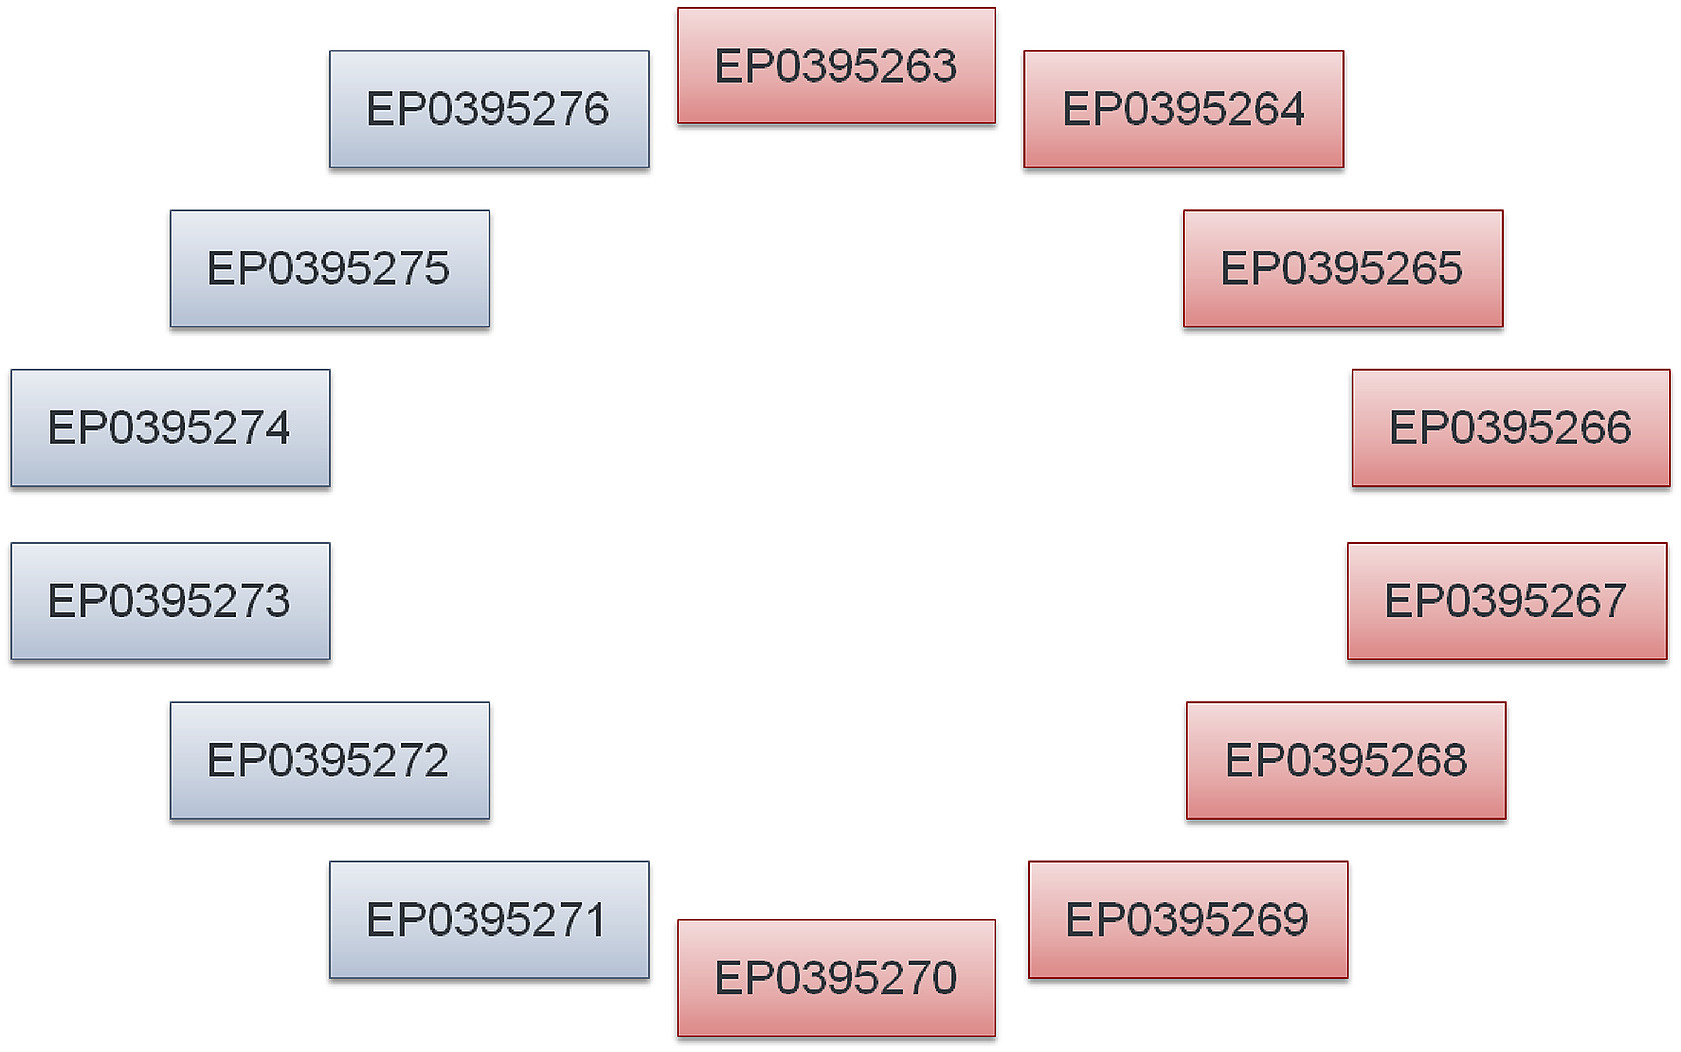

#### 7.5.3.1 Exploring Patent Data by Classifications
Search via CPCs in OPS by class ranking

In [11]:
# Consolidated function to print columns and filter EP patent numbers
def process_patent_data(content):
    print("Columns:")
    print(content.columns)

    # Filter and print EP patent numbers
    ep_patent_numbers = [
        patent for patent in content["ops:publication-reference|document-id"].tolist()
        if patent.get('country') == 'EP'
    ]
    ep_doc_numbers = [patent['doc-number'] for patent in ep_patent_numbers]
    print("EP Patent Numbers:")
    pprint(ep_doc_numbers)

# Generic function to perform the patent search
def perform_patent_search(cql_query, doc_start=1, doc_stop=20):
    content = client.published_data_search(
        cql=cql_query,
        range_begin=doc_start, 
        range_end=doc_stop, 
        output_type="dataframe"
    )
    process_patent_data(content)

In [12]:
cql_query = 'pn = "EP" AND ap <= 19900411 AND cpc = ("H04N7/014" OR "G06T7/231" OR "H04N7/0125" OR "G06T2207/10016")'
perform_patent_search(cql_query)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395276',
 '0395275',
 '0395274',
 '0395273',
 '0395272',
 '0395271',
 '0395270',
 '0395269',
 '0395268',
 '0395267',
 '0395266',
 '0395265',
 '0395264',
 '0395263']


#### 7.5.3.2 Exploring Patent Data by Country Code, Priority Date, Application Date and Applicant
This title reflects the method of filtering European patents based on specific criteria like title, priority date, application date, and applicant name.

In [13]:
cql_query = 'pn = "EP" AND pr="19890427" AND ap="19900411" AND pa="sony"'
perform_patent_search(cql_query, doc_stop=100)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395276',
 '0395275',
 '0395274',
 '0395273',
 '0395272',
 '0395271',
 '0395270',
 '0395269',
 '0395268',
 '0395267',
 '0395266',
 '0395265',
 '0395264',
 '0395263']


#### 7.5.3.3 Patent Searches by Priority Date, Applicant Date, Applicant and Inventors
This search find European patents with the same priority and application dates as the previous query, assigned to Sony, and involving any of the inventors Gillard, Samad, Richards, Walters, or Avis.

In [14]:
cql_query = 'pn = "EP" AND pa = "sony" AND in any "gillard, samad, richards, walters, avis" AND pr = "19890427" AND ap = "19900411"'
perform_patent_search(cql_query)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395276',
 '0395275',
 '0395274',
 '0395273',
 '0395272',
 '0395271',
 '0395270',
 '0395269',
 '0395268',
 '0395267',
 '0395266',
 '0395265',
 '0395264',
 '0395263']


#### 8.5.3.4 Patent Searches by Title, Priority Date, Applicant Date and Applicant.
This search focuses on retrieving European patents with any of the title words, the applicant and date filters, providing a more comprehensive understanding of relevant patents.

In [15]:
cql_query = 'pn = "EP" AND ti="motion dependent video signal processing" AND pr="19890427" AND ap="19900411" AND pa="sony"'
perform_patent_search(cql_query)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395275',
 '0395274',
 '0395273',
 '0395272',
 '0395271',
 '0395270',
 '0395269',
 '0395268',
 '0395267',
 '0395266',
 '0395265',
 '0395264',
 '0395263']


#### 7.5.3.5 Patent Searches by Title, Priority Date, Applicant Date, Inventors and Applicant.
This search focuses on retrieving European patents with any of the specified inventors alongside the title, applicant and date filters, providing a more comprehensive understanding of relevant related patents. Again retrieves the same group of related patents specifically, but may be aimed at confirming results of prior search results.

In [16]:
cql_query = 'pn = "EP" and in=("Gillard" or "Avis" or "Samad" or "Richards" or "Walters") and ti="motion dependent video signal processing" and pr="19890427" and ap="19900411" and pa="sony"'
perform_patent_search(cql_query)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395275',
 '0395274',
 '0395273',
 '0395272',
 '0395271',
 '0395270',
 '0395269',
 '0395268',
 '0395267',
 '0395266',
 '0395265',
 '0395264',
 '0395263']


#### 7.5.3.6 Perform a detection check
Excluding certain priorities already known from the eight files arrived at first: 
GB19890009643, GB19890009644, GB19890009645, GB19890009646, GB19890009647, GB19890009648, GB19890009649, GB19890009650

In [17]:
cql_query = 'pn = "EP" and (pr="19890427" not pr any "GB19890009643, GB19890009644, GB19890009645, GB19890009646, GB19890009647, GB19890009648, GB19890009649, GB19890009650") and ap="19900411" and pa="sony"'
perform_patent_search(cql_query)

Columns:
Index(['ops:publication-reference|system',
       'ops:publication-reference|family-id',
       'ops:publication-reference|document-id'],
      dtype='object')
EP Patent Numbers:
['0395276', '0395275', '0395274', '0395273', '0395272', '0395271']
